# Full Pipeline

### Parameterized pipeline for entire strategy. Assumes data has already been sourced with 00-source-data.py.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import coint
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from datasketch import MinHash, MinHashLSH

### Parameters

In [2]:
# --- PCA --- #
PCA_k = 10

# --- PageRank --- #
PR_CORR_THRESHOLD = 0.8
PR_NUM_ASSETS = 25
PR_BETA = 0.85

# --- Cointegration --- #
COINT_PVAL = 0.05

# --- GMM --- #
GMM_k_RANGE = [2, 3, 4]
GMM_CALM_ONLY = True
GMM_z_TRADE_THRESH = 1.0
GMM_z_EXIT_THRESH = 0.2

# --- Minhash --- #
MINHASH_NUM_PERM = 64
MINHASH_WINDOW_SIZE = 10
MINHASH_FORWARD_DAYS = 10
MINHASH_MIN_SIGNALS = 200

# --- Supervised Model --- #
USE_LR = False
USE_RFC = True

# --- Backtest --- #
SIGNAL_COLS = ['final_signal', 'model_signal']
COLORS      = {'final_signal': '#2196F3', 'model_signal': '#FF5722'}

In [3]:
run_dir = f"../data/runs/{PCA_k}_{PR_CORR_THRESHOLD}_{PR_NUM_ASSETS}_{GMM_CALM_ONLY}_{GMM_z_TRADE_THRESH}_{USE_RFC}"
os.makedirs(run_dir, exist_ok=True)
print(f"Folder '{run_dir}' created or already exists.")

fig_dir = run_dir + "/figs/"
os.makedirs(fig_dir, exist_ok=True)

Folder '../data/runs/10_0.8_25_True_1.0_True' created or already exists.


### Load Data

In [4]:
train_returns = pd.read_csv("../data/raw/equity_returns_train.csv", index_col=0, parse_dates=True)
val_returns   = pd.read_csv("../data/raw/equity_returns_val.csv",   index_col=0, parse_dates=True)
test_returns  = pd.read_csv("../data/raw/equity_returns_test.csv",  index_col=0, parse_dates=True)

### Dimension Reduction

In [5]:
# align columns - keep only tickers present in all splits
common_cols   = train_returns.columns.intersection(val_returns.columns).intersection(test_returns.columns)
train_returns = train_returns[common_cols]
val_returns   = val_returns[common_cols]
test_returns  = test_returns[common_cols]

scaler = StandardScaler()

scaled_train = pd.DataFrame(
    scaler.fit_transform(train_returns),
    index=train_returns.index,
    columns=train_returns.columns
)
scaled_val = pd.DataFrame(
    scaler.transform(val_returns),
    index=val_returns.index,
    columns=val_returns.columns
)
scaled_test = pd.DataFrame(
    scaler.transform(test_returns),
    index=test_returns.index,
    columns=test_returns.columns
)

pca = PCA(n_components=PCA_k)
pca.fit(scaled_train)

train_reconstructed = pca.inverse_transform(pca.transform(scaled_train))
train_residuals     = pd.DataFrame(
    train_returns.values - train_reconstructed,
    index=train_returns.index,
    columns=train_returns.columns
)

val_reconstructed = pca.inverse_transform(pca.transform(scaled_val))
val_residuals     = pd.DataFrame(
    val_returns.values - val_reconstructed,
    index=val_returns.index,
    columns=val_returns.columns
)

test_reconstructed = pca.inverse_transform(pca.transform(scaled_test))
test_residuals     = pd.DataFrame(
    test_returns.values - test_reconstructed,
    index=test_returns.index,
    columns=test_returns.columns
)

train_residuals.to_csv("../data/manipulated/residuals_train.csv")
val_residuals.to_csv("../data/manipulated/residuals_val.csv")
test_residuals.to_csv("../data/manipulated/residuals_test.csv")

full_residuals = pd.concat([train_residuals, val_residuals, test_residuals])
full_residuals.to_csv("../data/manipulated/residuals_full.csv")

train_start = train_residuals.index.min()
train_end   = train_residuals.index.max()
val_start   = val_residuals.index.min()
val_end     = val_residuals.index.max()
test_start  = test_residuals.index.min()
test_end    = test_residuals.index.max()

print(f'Train: {train_start.date()} to {train_end.date()} ({len(train_residuals)} rows)')
print(f'Val:   {val_start.date()} to {val_end.date()} ({len(val_residuals)} rows)')
print(f'Test:  {test_start.date()} to {test_end.date()} ({len(test_residuals)} rows)')
print(f'Assets: {len(common_cols)}')

Train: 2016-07-06 to 2023-12-29 (1885 rows)
Val:   2024-01-02 to 2024-12-31 (252 rows)
Test:  2025-01-02 to 2025-12-31 (250 rows)
Assets: 467


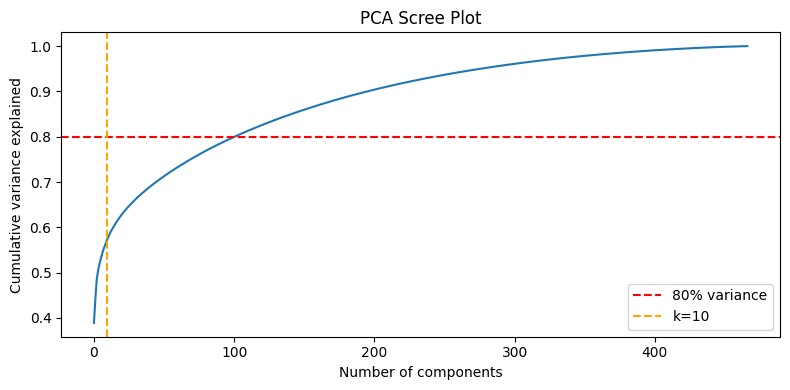

In [6]:
pca_full = PCA()
pca_full.fit(scaled_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_full.explained_variance_ratio_))
ax.axhline(0.8, color='red', linestyle='--', label='80% variance')
ax.axvline(PCA_k - 1, color='orange', linestyle='--', label=f'k={PCA_k}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'pca_scree.png', dpi=150)
plt.show()

### PageRank

In [7]:
train_corr = train_residuals.corr()

def pagerank(mtx, beta=PR_BETA, tol=1e-6, max_iter=100):
    A = mtx.to_numpy() if hasattr(mtx, "to_numpy") else mtx
    n = A.shape[0]
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P = A / row_sums
    r = np.ones(n) / n
    for _ in range(max_iter):
        r_new = beta * P.T @ r + (1 - beta) / n
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new
    return r

weight_matrix = train_corr.copy()
weight_matrix[train_corr <= PR_CORR_THRESHOLD] = 0
weight_matrix = weight_matrix ** 2
weight_matrix = weight_matrix.mask(np.eye(len(weight_matrix), dtype=bool), 0)

r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(PR_NUM_ASSETS)
print(top_assets)

    Asset  PageRank
80    CDW  0.004190
116  CTSH  0.004149
24   AMCR  0.004057
202   HAS  0.003974
307   NKE  0.003875
36    APH  0.003856
390   STZ  0.003834
258   LIN  0.003823
147    EL  0.003822
457    WY  0.003817
198  GRMN  0.003816
62    BLK  0.003788
37    APO  0.003786
211   HPQ  0.003785
142   ECL  0.003752
108   CRH  0.003694
40   ARES  0.003692
246   KKR  0.003680
76   CBRE  0.003679
329  PAYX  0.003677
113   CSX  0.003645
5     ACN  0.003612
231    IT  0.003596
402   TEL  0.003569
296   MSI  0.003568


/tmp/ipykernel_9028/3740759503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis", ax=ax)


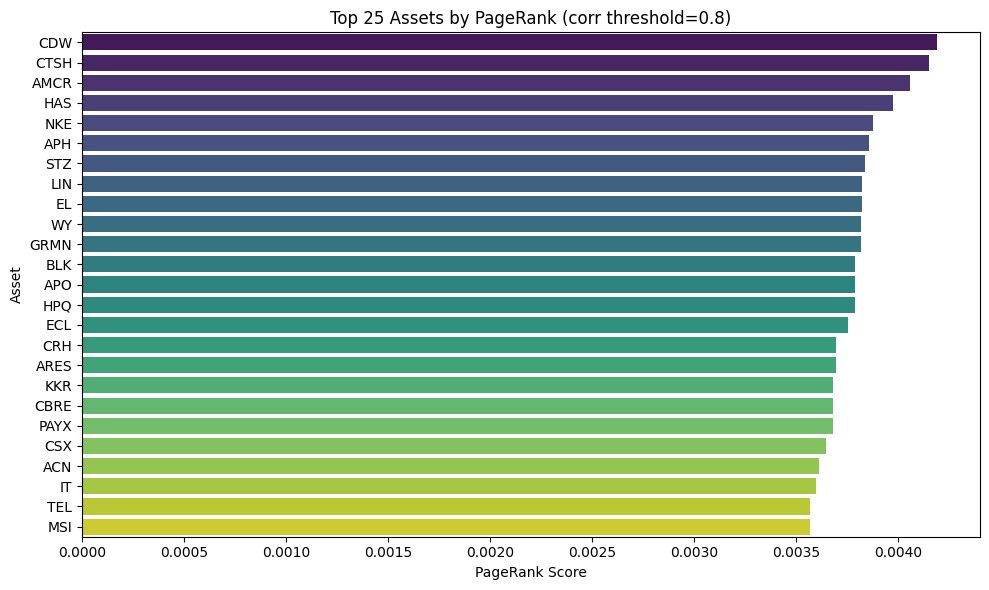

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis", ax=ax)
ax.set_title(f'Top {PR_NUM_ASSETS} Assets by PageRank (corr threshold={PR_CORR_THRESHOLD})')
ax.set_xlabel('PageRank Score')
ax.set_ylabel('Asset')
plt.tight_layout()
plt.savefig(fig_dir + 'pagerank_top_assets.png', dpi=150)
plt.show()

filtered_residuals = full_residuals[top_assets["Asset"]]
filtered_residuals.to_csv("../data/manipulated/pr_filtered_residuals.csv", index=True)
filtered_train_residuals = filtered_residuals.loc[train_start:train_end]

### Cointegration

In [9]:
assets = filtered_train_residuals.columns

def find_cointegrated_pairs(residuals_df, candidates, pvalue_threshold=COINT_PVAL):
    pairs = []
    tickers = list(candidates)
    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            a, b = tickers[i], tickers[j]
            _, pvalue, _ = coint(residuals_df[a], residuals_df[b])
            if pvalue < pvalue_threshold:
                model = LinearRegression().fit(residuals_df[[b]], residuals_df[a])
                beta = model.coef_[0]
                pairs.append((a, b, pvalue, beta))
    pairs_df = pd.DataFrame(pairs, columns=["asset_a", "asset_b", "pvalue", "beta"])
    return pairs_df.sort_values("pvalue")

cointegrated_pairs = find_cointegrated_pairs(filtered_train_residuals, assets, pvalue_threshold=COINT_PVAL)
cointegrated_pairs.to_csv("../data/manipulated/cointegrated_pairs.csv", index=False)
print(f'{len(cointegrated_pairs)} cointegrated pairs found')
cointegrated_pairs.head()

300 cointegrated pairs found


,asset_a,asset_b,pvalue,beta
296,ACN,MSI,0.0,1.151615
2,CDW,HAS,0.0,1.245633
42,CTSH,CSX,0.0,0.874569
43,CTSH,ACN,0.0,0.832885
50,AMCR,STZ,0.0,0.967045


### GMM Regimes

In [10]:
def select_best_k(spread, k_range=GMM_k_RANGE):
    X = spread.values.reshape(-1, 1)
    bic_scores = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
        gmm.fit(X)
        bic_scores.append((k, gmm.bic(X)))
    return min(bic_scores, key=lambda x: x[1])[0]

def fit_gmm(spread, n_components):
    X = spread.values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, covariance_type="full", random_state=42, n_init=5)
    gmm.fit(X)
    return gmm

os.makedirs("../data/manipulated/spreads", exist_ok=True)

for _, row in cointegrated_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']

    train_spread = filtered_train_residuals[a] - beta * filtered_train_residuals[b]
    full_spread  = filtered_residuals[a] - beta * filtered_residuals[b]

    best_k = select_best_k(train_spread)
    gmm    = fit_gmm(train_spread, best_k)
    labels = gmm.predict(full_spread.values.reshape(-1, 1))

    sorted_idx    = np.argsort(gmm.means_.flatten())
    remap         = {old: new for new, old in enumerate(sorted_idx)}
    sorted_labels = np.array([remap[l] for l in labels])

    train_mean = train_spread.mean()
    train_std  = train_spread.std()
    z_scores   = (full_spread - train_mean) / train_std

    sorted_stds = np.sqrt(gmm.covariances_.flatten())[sorted_idx]
    calm_regime = int(np.argmin(sorted_stds))

    signal = pd.Series(0, index=full_spread.index)
    if GMM_CALM_ONLY:
        signal[(z_scores < -GMM_z_TRADE_THRESH) & (sorted_labels == calm_regime)] =  1
        signal[(z_scores >  GMM_z_TRADE_THRESH) & (sorted_labels == calm_regime)] = -1
    else:
        signal[z_scores < -GMM_z_TRADE_THRESH] =  1
        signal[z_scores >  GMM_z_TRADE_THRESH] = -1
    signal[z_scores.abs() < GMM_z_EXIT_THRESH] = 0

    df = pd.DataFrame({
        'spread':  full_spread.values,
        'regime':  sorted_labels,
        'z_score': z_scores.values,
        'gmm_signal':  signal.values,
    }, index=full_spread.index)

    df.to_csv(f'../data/manipulated/spreads/{a}_{b}.csv')

print(f'Saved {len(cointegrated_pairs)} spread files')

Saved 300 spread files


### MinHash

In [11]:
MIN_SIGNALS = MINHASH_MIN_SIGNALS

def discretise(spread_window):
    mean = spread_window.mean()
    std  = spread_window.std()
    z    = (spread_window - mean) / std
    symbols = []
    for val in z:
        if val < -1.5:   symbols.append('--')
        elif val < -0.3: symbols.append('-')
        elif val <  0.3: symbols.append('0')
        elif val <  1.5: symbols.append('+')
        else:            symbols.append('++')
    return symbols

def shingle(symbols, k=3):
    return set(''.join(symbols[i:i+k]) for i in range(len(symbols) - k + 1))

def make_minhash(shingles, num_perm=MINHASH_NUM_PERM):
    m = MinHash(num_perm=num_perm)
    for s in shingles:
        m.update(s.encode('utf-8'))
    return m

def build_lsh_index(spread, window_size=MINHASH_WINDOW_SIZE, num_perm=MINHASH_NUM_PERM):
    lsh = MinHashLSH(threshold=0.5, num_perm=num_perm)
    signatures = {}
    for i in range(len(spread) - window_size):
        window = spread.iloc[i:i + window_size]
        m = make_minhash(shingle(discretise(window)))
        key = f"w_{i}"
        lsh.insert(key, m)
        signatures[key] = (m, i)
    return lsh, signatures

def compute_minhash_signals(spread, gmm_signals, lsh, signatures,
                             window_size=MINHASH_WINDOW_SIZE, forward_days=MINHASH_FORWARD_DAYS):
    minhash_signals = pd.Series(0.0, index=spread.index)
    signal_days = gmm_signals[gmm_signals != 0].index
    for date in signal_days:
        i = spread.index.get_loc(date)
        if i < window_size:
            continue
        window = spread.iloc[i - window_size:i]
        query_m = make_minhash(shingle(discretise(window)))
        similar_keys = lsh.query(query_m)
        if not similar_keys:
            continue
        forward_returns = []
        for key in similar_keys:
            _, start_idx = signatures[key]
            end_idx = start_idx + window_size + forward_days
            if end_idx < len(spread) and start_idx + window_size <= i:
                fwd = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
                forward_returns.append(fwd)
        if forward_returns:
            minhash_signals.loc[date] = np.mean(forward_returns)
    return minhash_signals

def combine_signals(gmm_signal, minhash_signal):
    if gmm_signal == 0:
        return 0
    if gmm_signal == 1 and minhash_signal > 0:
        return 1
    if gmm_signal == -1 and minhash_signal < 0:
        return -1
    return 0

# filter to active pairs (enough GMM signals)
active_pairs_list = []
for _, row in cointegrated_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    df = pd.read_csv(f'../data/manipulated/spreads/{a}_{b}.csv', index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    n_signals = (df['gmm_signal'] != 0).sum()
    if n_signals >= MIN_SIGNALS:
        active_pairs_list.append(row)
        print(f"{a}/{b} — {n_signals} signals, keeping")
    else:
        print(f"{a}/{b} — {n_signals} signals, dropping")

active_pairs = pd.DataFrame(active_pairs_list)
active_pairs.to_csv("../data/manipulated/active_pairs.csv")
print(f"\n{len(active_pairs)} pairs kept from {len(cointegrated_pairs)}")

ACN/MSI — 227 signals, keeping
CDW/HAS — 216 signals, keeping
CTSH/CSX — 181 signals, dropping
CTSH/ACN — 198 signals, dropping
AMCR/STZ — 126 signals, dropping
AMCR/APH — 165 signals, dropping
CTSH/MSI — 153 signals, dropping
CTSH/IT — 224 signals, keeping
AMCR/BLK — 147 signals, dropping
AMCR/EL — 181 signals, dropping
AMCR/APO — 0 signals, dropping
APO/CSX — 77 signals, dropping
AMCR/MSI — 195 signals, dropping
AMCR/IT — 207 signals, keeping
AMCR/ACN — 150 signals, dropping
AMCR/ARES — 266 signals, keeping
APO/MSI — 283 signals, keeping
HPQ/CRH — 140 signals, dropping
HPQ/KKR — 0 signals, dropping
HPQ/ACN — 179 signals, dropping
HPQ/IT — 73 signals, dropping
APO/ACN — 188 signals, dropping
APO/IT — 0 signals, dropping
APO/TEL — 78 signals, dropping
ECL/ACN — 168 signals, dropping
HPQ/TEL — 150 signals, dropping
ECL/MSI — 159 signals, dropping
GRMN/ACN — 232 signals, keeping
GRMN/ARES — 343 signals, keeping
GRMN/ECL — 103 signals, dropping
CRH/KKR — 0 signals, dropping
CRH/ARES — 0 s

In [12]:
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)

    full_spread  = df['spread']
    train_spread = full_spread.loc[train_start:train_end]
    lsh, signatures = build_lsh_index(train_spread)

    minhash_signals = compute_minhash_signals(full_spread, df['gmm_signal'], lsh, signatures)

    df['minhash_signal'] = minhash_signals
    df['final_signal']   = df.apply(
        lambda r: combine_signals(r['gmm_signal'], r['minhash_signal']), axis=1
    )
    df.to_csv(path)
    print(f"done: {a}/{b}")

done: ACN/MSI
done: CDW/HAS
done: CTSH/IT
done: AMCR/IT
done: AMCR/ARES
done: APO/MSI
done: GRMN/ACN
done: GRMN/ARES
done: HAS/IT
done: BLK/ARES
done: GRMN/IT
done: BLK/IT
done: BLK/CSX
done: NKE/EL
done: HAS/CRH
done: EL/CSX
done: EL/APO
done: CTSH/STZ
done: APH/CRH
done: STZ/IT
done: STZ/ECL
done: EL/TEL
done: WY/HPQ
done: NKE/IT
done: WY/ARES
done: APH/APO
done: APH/EL
done: CTSH/AMCR
done: KKR/TEL
done: CBRE/TEL
done: CBRE/IT
done: HAS/APO
done: HAS/CSX
done: WY/CSX
done: GRMN/MSI
done: EL/ARES
done: CDW/CSX
done: EL/GRMN
done: APH/CSX
done: CDW/APO
done: CTSH/ARES
done: STZ/BLK
done: STZ/CSX
done: LIN/BLK
done: CDW/AMCR
done: CDW/WY
done: CTSH/CRH
done: LIN/CSX
done: CTSH/KKR
done: CDW/EL
done: CDW/CBRE
done: ECL/KKR
done: APH/WY
done: STZ/ARES
done: CDW/STZ
done: APH/CBRE
done: APH/KKR
done: AMCR/KKR
done: STZ/CBRE
done: STZ/CRH
done: STZ/KKR
done: AMCR/CBRE
done: GRMN/BLK
done: AMCR/HAS
done: LIN/EL
done: NKE/STZ
done: GRMN/KKR
done: CTSH/PAYX
done: CTSH/ECL
done: ARES/KKR
done:

### Supervised Model

In [14]:
FEATURES = ["spread", "z_score", "regime"]
TARGET   = "final_signal"

train_frames, val_frames, test_frames = [], [], []

for _, row in active_pairs.iterrows():
    path = f'../data/manipulated/spreads/{row["asset_a"]}_{row["asset_b"]}.csv'
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    df   = df[FEATURES + [TARGET]].dropna()
    train_frames.append(df.loc[train_start:train_end])
    val_frames.append(df.loc[val_start:val_end])
    test_frames.append(df.loc[test_start:test_end])

train_df = pd.concat(train_frames)
val_df   = pd.concat(val_frames)
test_df  = pd.concat(test_frames)

print(f'Train rows: {len(train_df):,}  | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}')
print('Train class distribution:')
print(train_df[TARGET].value_counts().sort_index())

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val   = val_df[FEATURES].values
y_val   = val_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

feat_scaler = StandardScaler()
X_train = feat_scaler.fit_transform(X_train)
X_val   = feat_scaler.transform(X_val)
X_test  = feat_scaler.transform(X_test)

Train rows: 209,235  | Val rows: 27,972 | Test rows: 27,750
Train class distribution:
final_signal
-1      7151
 0    193713
 1      8371
Name: count, dtype: int64


=== Random Forest — Train ===
              precision    recall  f1-score   support

  Short (-1)       0.38      1.00      0.55      7151
    Exit (0)       1.00      0.89      0.94    193713
    Long (1)       0.44      1.00      0.61      8371

    accuracy                           0.89    209235
   macro avg       0.61      0.96      0.70    209235
weighted avg       0.96      0.89      0.91    209235

=== Random Forest — Val ===
              precision    recall  f1-score   support

  Short (-1)       0.30      1.00      0.46       711
    Exit (0)       1.00      0.88      0.93     26445
    Long (1)       0.34      0.99      0.50       816

    accuracy                           0.88     27972
   macro avg       0.54      0.96      0.63     27972
weighted avg       0.96      0.88      0.91     27972



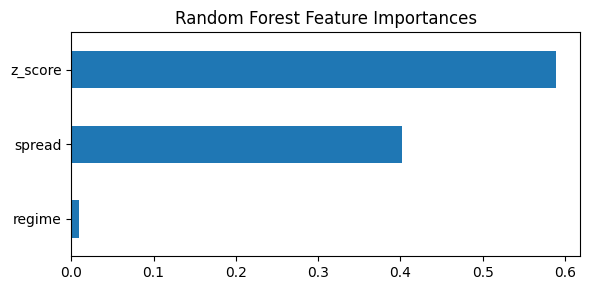

In [17]:
if USE_LR:
    model = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    print('=== Logistic Regression — Train ===')
    print(classification_report(y_train, model.predict(X_train), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))
    print('=== Logistic Regression — Val ===')
    print(classification_report(y_val, model.predict(X_val), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

if USE_RFC:
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=8, random_state=42)
    model.fit(X_train, y_train)
    print('=== Random Forest — Train ===')
    print(classification_report(y_train, model.predict(X_train), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))
    print('=== Random Forest — Val ===')
    print(classification_report(y_val, model.predict(X_val), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(6, 3))
    importances.plot(kind='barh', ax=ax)
    ax.set_title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.savefig(fig_dir + 'rf_feature_importances.png', dpi=150)
    plt.show()

In [18]:
# write model_signal back to each spread CSV
for _, row in active_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    path = f"../data/manipulated/spreads/{a}_{b}.csv"
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    valid = df[FEATURES].dropna()
    X = feat_scaler.transform(valid.values)
    df.loc[valid.index, "model_signal"] = model.predict(X)
    df.to_csv(path)

print(f"model_signal written to {len(active_pairs)} spread files")

model_signal written to 111 spread files


### Backtest

In [19]:
def compute_pair_pnl(signal: pd.Series, spread: pd.Series) -> pd.Series:
    """
    Daily spread change PnL.
      signal +1  => long spread  => earn spread_t - spread_{t-1}
      signal -1  => short spread => earn -(spread_t - spread_{t-1})
    1-bar lag: signal seen at close of t, position taken at t+1.
    """
    spread_ret = spread.diff()
    position   = signal.shift(1).fillna(0)
    return (position * spread_ret).rename(signal.name)

def backtest_metrics(log_ret: pd.Series, periods_per_year=252) -> dict:
    total   = log_ret.sum()
    ann_ret = log_ret.mean() * periods_per_year
    vol     = log_ret.std() * np.sqrt(periods_per_year)
    sharpe  = ann_ret / vol if vol > 0 else np.nan
    cum     = log_ret.cumsum()
    max_dd  = (cum - cum.cummax()).min()
    nonzero = log_ret[log_ret != 0]
    hit_rate = (nonzero > 0).mean() if len(nonzero) else np.nan
    return {
        'Total log return': round(total, 4),
        'Ann. log return':  round(ann_ret, 4),
        'Ann. volatility':  round(vol, 4),
        'Sharpe ratio':     round(sharpe, 3),
        'Max drawdown':     round(max_dd, 4),
        'Hit rate':         round(hit_rate, 3),
        'Active days':      int((log_ret != 0).sum()),
    }

def run_backtest(period_start, period_end, label):
    pair_pnl = {col: [] for col in SIGNAL_COLS}
    for _, row in active_pairs.iterrows():
        a, b = row['asset_a'], row['asset_b']
        path = f'../data/manipulated/spreads/{a}_{b}.csv'
        try:
            df = pd.read_csv(path, index_col=0, parse_dates=True)
        except FileNotFoundError:
            continue
        missing = [c for c in SIGNAL_COLS if c not in df.columns]
        if missing:
            continue
        period_df = df.loc[period_start:period_end].dropna(subset=SIGNAL_COLS + ['spread'])
        if len(period_df) < 10:
            continue
        for col in SIGNAL_COLS:
            pnl = compute_pair_pnl(period_df[col], period_df['spread'])
            pair_pnl[col].append(pnl.rename(f'{a}_{b}'))

    portfolio = {}
    for col in SIGNAL_COLS:
        all_series     = pd.concat(pair_pnl[col], axis=1).fillna(0)
        portfolio[col] = all_series.sum(axis=1) / all_series.shape[1]

    portfolio_df = pd.DataFrame(portfolio)
    cumulative   = portfolio_df.cumsum()

    print(f'\n=== {label} — Portfolio daily log-return stats ===')
    print(portfolio_df.describe().round(6))

    metrics = pd.DataFrame(
        {col: backtest_metrics(portfolio_df[col]) for col in SIGNAL_COLS}
    )
    print(f'\n=== {label} — Metrics ===')
    print(metrics)

    # cumulative PnL
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in SIGNAL_COLS:
        cumulative[col].plot(ax=ax, label=col, color=COLORS[col], linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Cumulative Log Return — {label} (Equal-Weighted, Asset A)')
    ax.set_ylabel('Cumulative Log Return')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'cumulative_pnl_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # drawdown
    fig, ax = plt.subplots(figsize=(12, 4))
    for col in SIGNAL_COLS:
        cum = cumulative[col]
        dd  = cum - cum.cummax()
        dd.plot(ax=ax, label=col, color=COLORS[col], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Drawdown — {label}')
    ax.set_ylabel('Drawdown (log return)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'drawdown_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # per-pair bar chart (val only, for manageable size)
    final_totals = {s.name: s.sum() for s in pair_pnl['final_signal']}
    lr_totals    = {s.name: s.sum() for s in pair_pnl['model_signal']}
    pairs_sorted = sorted(final_totals.keys())
    x = np.arange(len(pairs_sorted))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(12, len(pairs_sorted) * 0.4), 5))
    ax.bar(x - width/2, [final_totals[p] for p in pairs_sorted], width, label='final_signal', color=COLORS['final_signal'], alpha=0.8)
    ax.bar(x + width/2, [lr_totals.get(p, 0) for p in pairs_sorted],    width, label='model_signal',    color=COLORS['model_signal'],    alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs_sorted, rotation=90, fontsize=7)
    ax.set_title(f'Per-Pair Total Log Return — {label}')
    ax.set_ylabel('Total Log Return')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'per_pair_pnl_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # rolling sharpe (30-day)
    fig, ax = plt.subplots(figsize=(12, 4))
    for col in SIGNAL_COLS:
        roll = portfolio_df[col].rolling(30)
        rolling_sharpe = (roll.mean() / roll.std()) * np.sqrt(252)
        rolling_sharpe.plot(ax=ax, label=col, color=COLORS[col], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Rolling 30-Day Sharpe — {label}')
    ax.set_ylabel('Sharpe')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'rolling_sharpe_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return portfolio_df, metrics, pair_pnl


=== Train — Portfolio daily log-return stats ===
       final_signal  model_signal
count   1885.000000   1885.000000
mean       0.023151      0.060195
std        0.023725      0.057679
min       -0.055657     -0.093186
25%        0.003920      0.009030
50%        0.017956      0.048738
75%        0.036106      0.097567
max        0.286658      0.508045

=== Train — Metrics ===
                  final_signal  model_signal
Total log return       43.6401      113.4684
Ann. log return         5.8341       15.1692
Ann. volatility         0.3766        0.9156
Sharpe ratio           15.4900       16.5670
Max drawdown           -0.0557       -0.0932
Hit rate                0.9540        0.9620
Active days          1620.0000     1672.0000


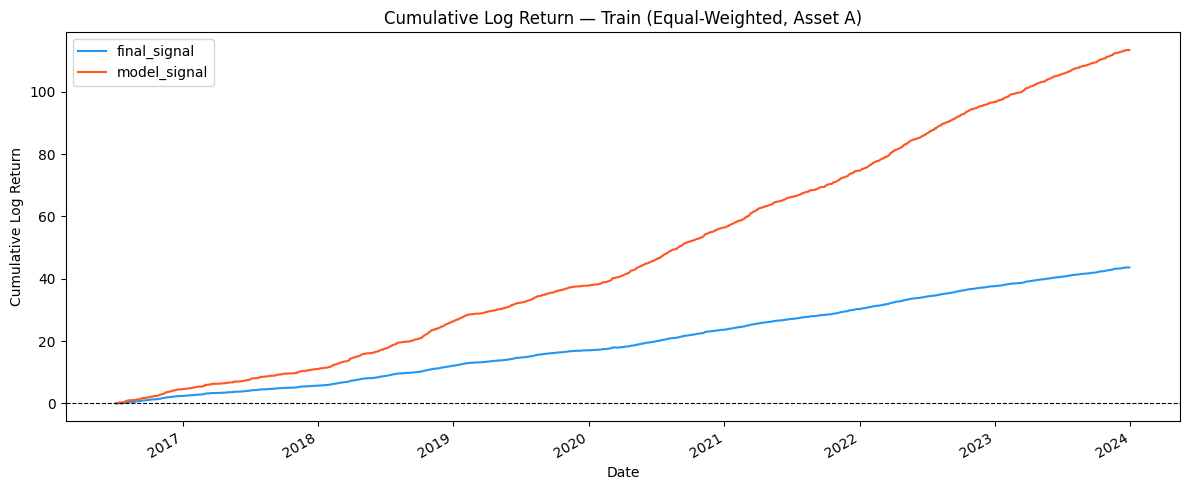

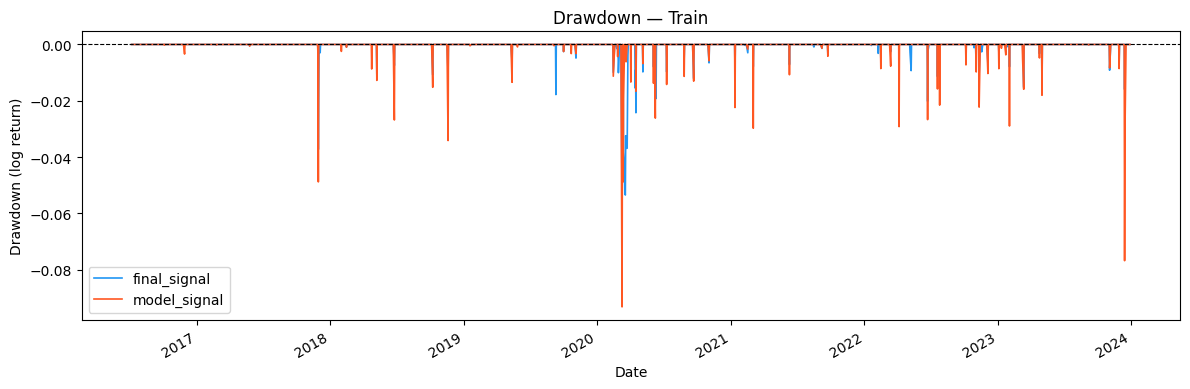

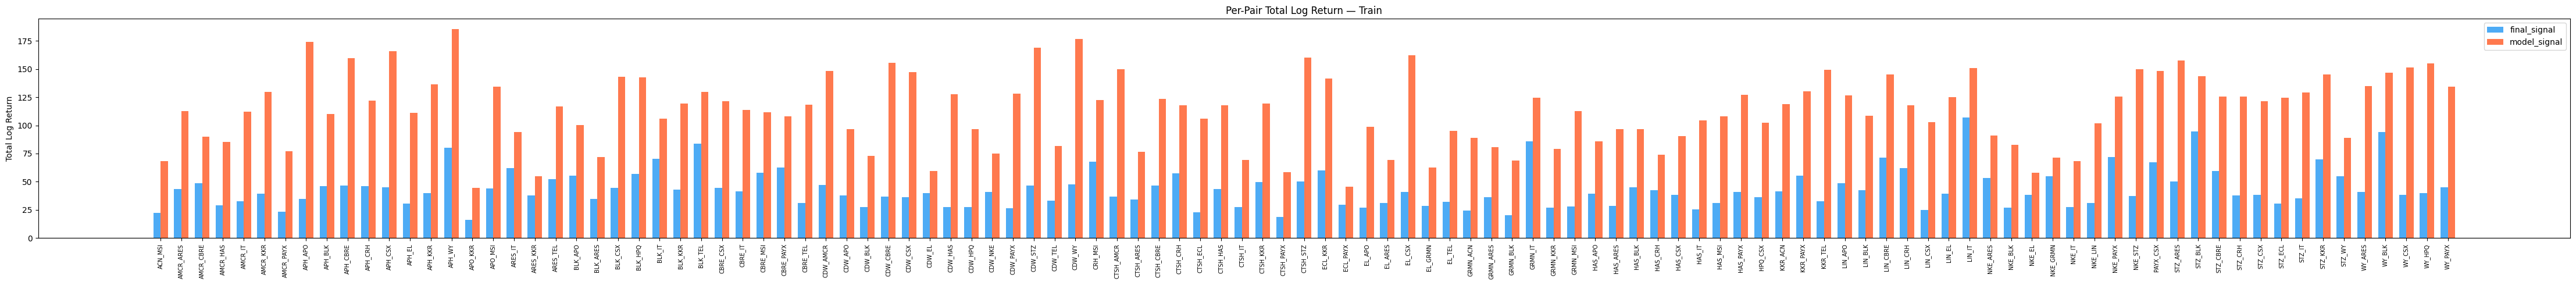

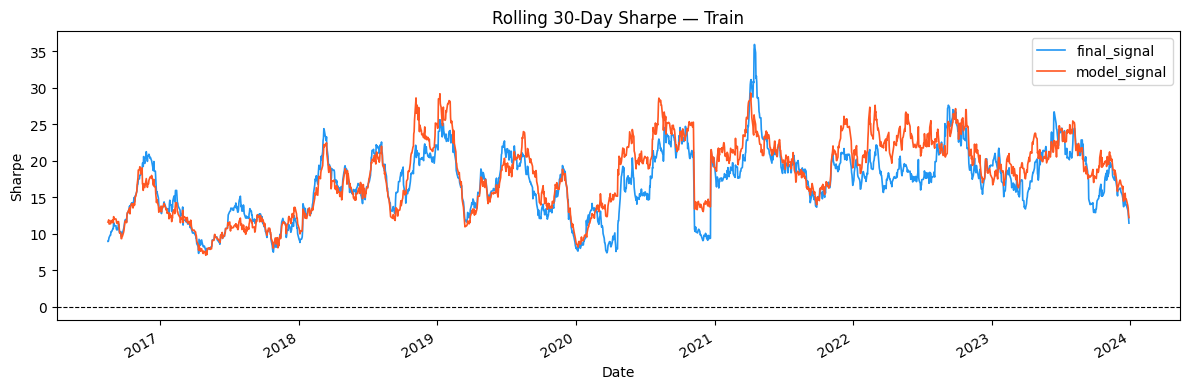

In [20]:
train_portfolio, train_metrics, train_pair_pnl = run_backtest(train_start, train_end, "Train")


=== Validation — Portfolio daily log-return stats ===
       final_signal  model_signal
count    252.000000    252.000000
mean       0.018436      0.062818
std        0.017924      0.057077
min       -0.012128     -0.025684
25%        0.003367      0.013744
50%        0.014332      0.047516
75%        0.028372      0.103522
max        0.095271      0.256486

=== Validation — Metrics ===
                  final_signal  model_signal
Total log return        4.6459       15.8302
Ann. log return         4.6459       15.8302
Ann. volatility         0.2845        0.9061
Sharpe ratio           16.3280       17.4710
Max drawdown           -0.0121       -0.0257
Hit rate                0.9820        0.9830
Active days           218.0000      232.0000


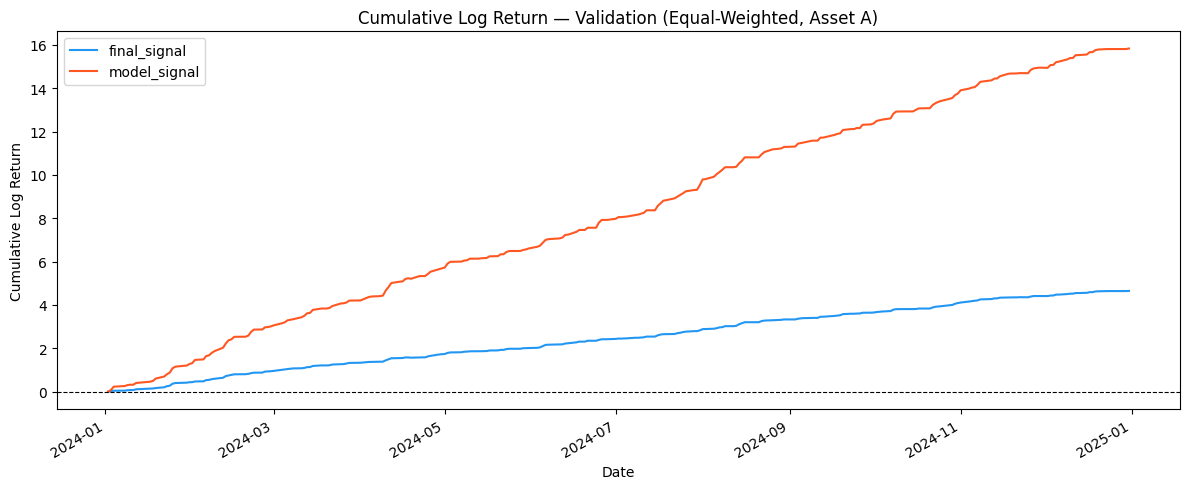

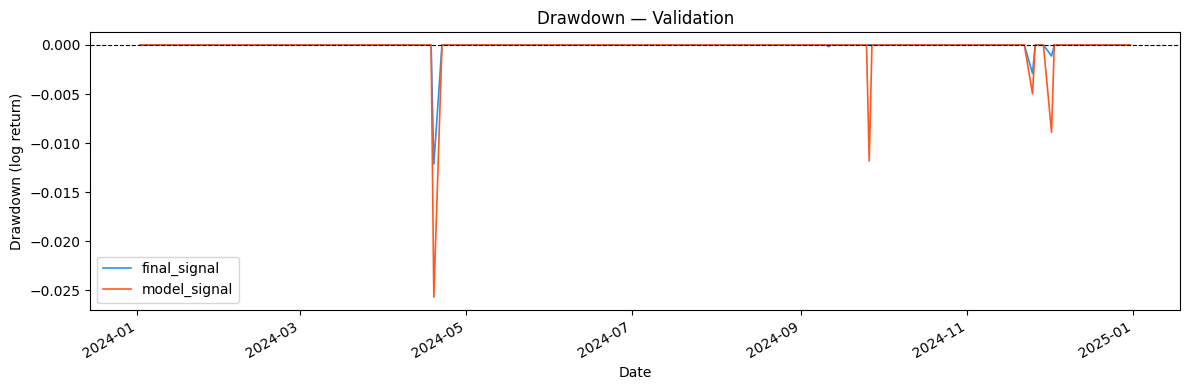

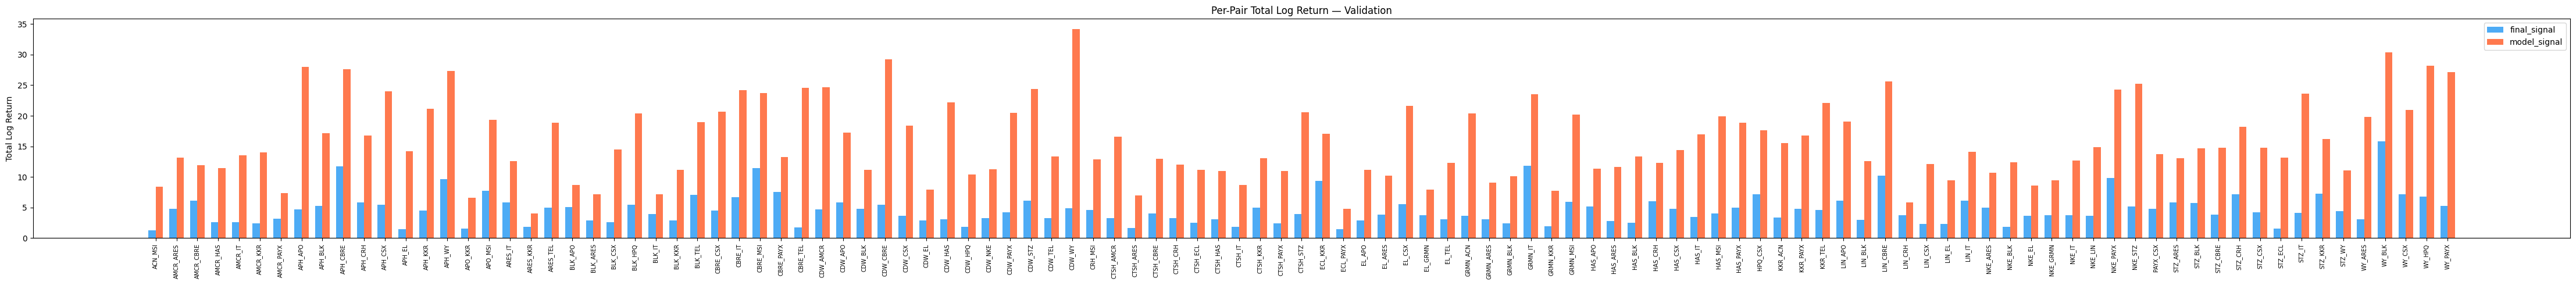

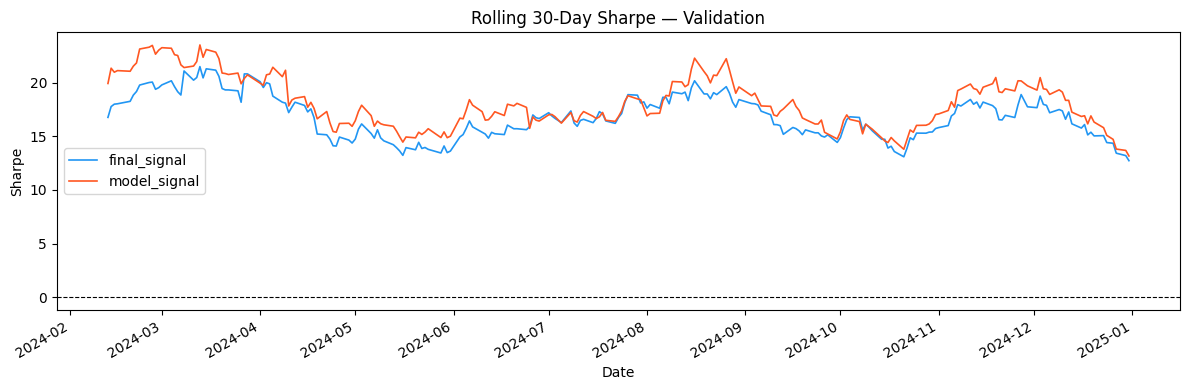

In [21]:
val_portfolio, val_metrics, val_pair_pnl = run_backtest(val_start, val_end, "Validation")

### Regime-Conditional PnL (Validation)

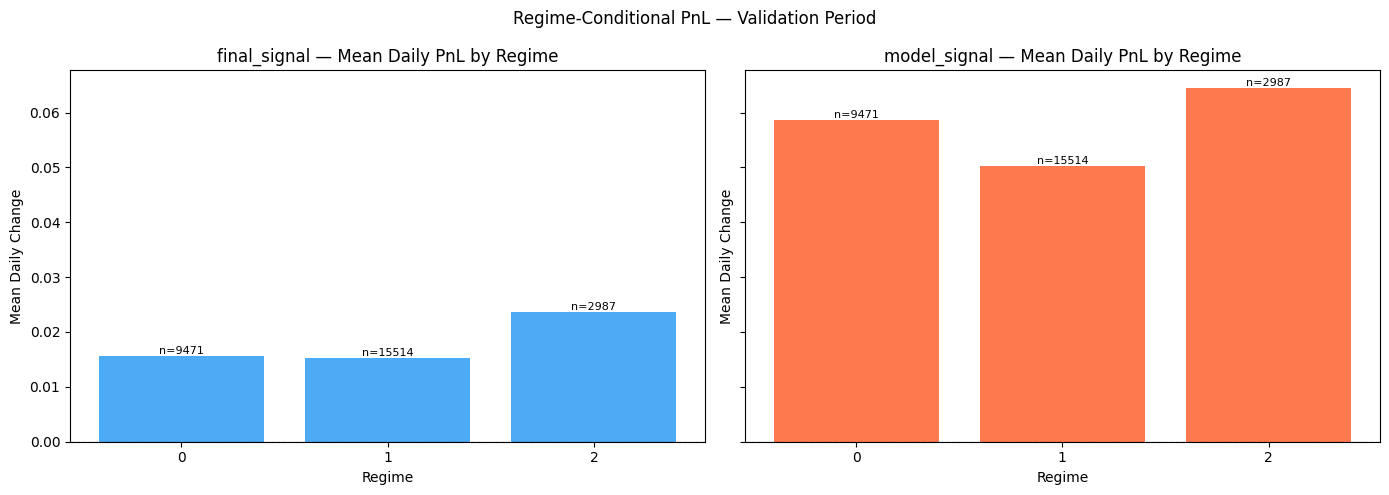

In [42]:
# For each pair on val set, split daily PnL by regime and aggregate
regime_pnl = {}  # (signal, regime_id) -> list of pnl values

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'

    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue

    if a not in filtered_residuals.columns:
        continue

    # align validation window
    period_df = df.loc[val_start:val_end]
    series = filtered_residuals[a].loc[val_start:val_end]

    shared_idx = period_df.index.intersection(series.index)
    if len(shared_idx) < 10:
        continue

    period_df = period_df.loc[shared_idx]
    series = series.loc[shared_idx]

    # ✅ USE DIFFERENCES (NOT LOG RETURNS)
    returns = series.diff().fillna(0)

    for col in SIGNAL_COLS:
        position = period_df[col].shift(1).fillna(0)

        daily_pnl = position * returns

        for regime_id in period_df['regime'].unique():
            mask = period_df['regime'] == regime_id
            key = (col, int(regime_id))

            if key not in regime_pnl:
                regime_pnl[key] = []

            regime_pnl[key].extend(daily_pnl[mask].dropna().tolist())


# plot mean daily PnL by regime for each signal
fig, axes = plt.subplots(1, len(SIGNAL_COLS), figsize=(14, 5), sharey=True)

for ax, col in zip(axes, SIGNAL_COLS):
    regime_ids = sorted(set(k[1] for k in regime_pnl if k[0] == col))

    means = [np.mean(regime_pnl[(col, r)]) if len(regime_pnl[(col, r)]) > 0 else 0
             for r in regime_ids]

    counts = [len(regime_pnl[(col, r)]) for r in regime_ids]

    bars = ax.bar([str(r) for r in regime_ids],
                  means,
                  color=COLORS[col],
                  alpha=0.8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{col} — Mean Daily PnL by Regime')
    ax.set_xlabel('Regime')
    ax.set_ylabel('Mean Daily Change')

    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f'n={n}',
                ha='center',
                va='bottom',
                fontsize=8)

plt.suptitle('Regime-Conditional PnL — Validation Period')
plt.tight_layout()
plt.savefig(fig_dir + 'regime_pnl_val.png', dpi=150)
plt.show()

### Intermediate Signal Agreement Analysis

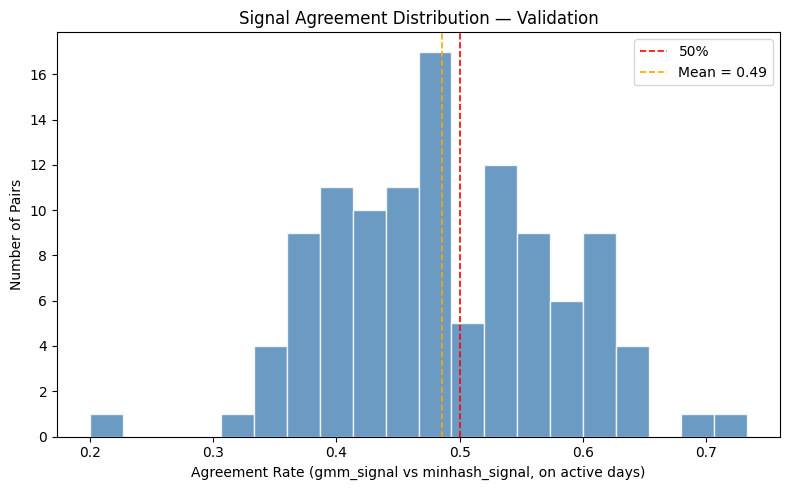

       agreement  n_signals
count    111.000    111.000
mean       0.486     28.315
std        0.091      8.575
min        0.200     15.000
25%        0.420     23.000
50%        0.478     26.000
75%        0.556     31.500
max        0.733     57.000


In [41]:
# How often do final_signal and model_signal agree on val set?
agreement_stats = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue

    val_df_pair = df.loc[val_start:val_end]
    active_mask = ~(
    (val_df_pair['gmm_signal'] == 0) &
    (val_df_pair['minhash_signal'] == 0)
    )
    
    if active_mask.sum() == 0:
        continue

    active = val_df_pair[active_mask]
    agreement = (np.sign(active['gmm_signal']) == np.sign(active['minhash_signal'])).mean()
    agreement_stats.append({'pair': f'{a}_{b}', 'agreement': agreement, 'n_signals': active_mask.sum()})

agreement_df = pd.DataFrame(agreement_stats).sort_values('agreement')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(agreement_df['agreement'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='50%')
ax.axvline(agreement_df['agreement'].mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Mean = {agreement_df["agreement"].mean():.2f}')
ax.set_xlabel('Agreement Rate (gmm_signal vs minhash_signal, on active days)')
ax.set_ylabel('Number of Pairs')
ax.set_title('Signal Agreement Distribution — Validation')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'signal_agreement_val.png', dpi=150)
plt.show()

print(agreement_df.describe().round(3))

### Final Signal Agreement Analysis

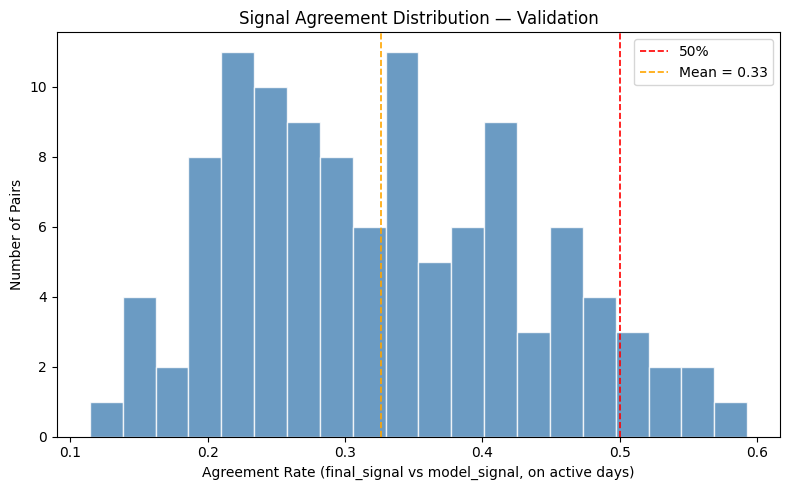

       agreement  n_signals
count    111.000    111.000
mean       0.326     43.234
std        0.108     10.027
min        0.114     19.000
25%        0.238     36.000
50%        0.317     44.000
75%        0.409     49.500
max        0.593     66.000


In [36]:
# How often do final_signal and model_signal agree on val set?
agreement_stats = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue
    if 'model_signal' not in df.columns:
        continue

    val_df_pair = df.loc[val_start:val_end]
    active_mask = ~(
    (val_df_pair['final_signal'] == 0) &
    (val_df_pair['model_signal'] == 0)
    )
    if active_mask.sum() == 0:
        continue

    active = val_df_pair[active_mask]
    agreement = (active['final_signal'] == active['model_signal']).mean()
    agreement_stats.append({'pair': f'{a}_{b}', 'agreement': agreement, 'n_signals': active_mask.sum()})

agreement_df = pd.DataFrame(agreement_stats).sort_values('agreement')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(agreement_df['agreement'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='50%')
ax.axvline(agreement_df['agreement'].mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Mean = {agreement_df["agreement"].mean():.2f}')
ax.set_xlabel('Agreement Rate (final_signal vs model_signal, on active days)')
ax.set_ylabel('Number of Pairs')
ax.set_title('Signal Agreement Distribution — Validation')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'signal_agreement_val.png', dpi=150)
plt.show()

print(agreement_df.describe().round(3))

In [29]:
print(agreement_df.shape)
print(agreement_df['agreement'].describe())
print(agreement_df['agreement'].value_counts().head(10))

(111, 3)
count    111.000000
mean       0.996550
std        0.020179
min        0.842105
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: agreement, dtype: float64
agreement
1.000000    107
0.842105      1
0.875000      1
0.933333      1
0.966667      1
Name: count, dtype: int64


### Save Metrics

In [26]:
train_metrics.to_csv(run_dir + '/train_metrics.csv')
val_metrics.to_csv(run_dir + '/val_metrics.csv')
print('Train metrics:')
print(train_metrics)
print('\nVal metrics:')
print(val_metrics)

Train metrics:
                  final_signal  model_signal
Total log return       43.6401      113.4684
Ann. log return         5.8341       15.1692
Ann. volatility         0.3766        0.9156
Sharpe ratio           15.4900       16.5670
Max drawdown           -0.0557       -0.0932
Hit rate                0.9540        0.9620
Active days          1620.0000     1672.0000

Val metrics:
                  final_signal  model_signal
Total log return        4.6459       15.8302
Ann. log return         4.6459       15.8302
Ann. volatility         0.2845        0.9061
Sharpe ratio           16.3280       17.4710
Max drawdown           -0.0121       -0.0257
Hit rate                0.9820        0.9830
Active days           218.0000      232.0000


### Additional Backtest - Profitable Pairs Only

In [27]:
# filter to pairs profitable on final_signal in training
profitable_pairs_list = []
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    matches = [s for s in train_pair_pnl['final_signal'] if s.name == f'{a}_{b}']
    if matches and matches[0].sum() > 0:
        profitable_pairs_list.append(row)

profitable_pairs_df = pd.DataFrame(profitable_pairs_list).reset_index(drop=True)
print(f'{len(profitable_pairs_df)} / {len(active_pairs)} pairs profitable in training:')
print(f'Percent of pairs profitable: {100*len(profitable_pairs_df)/len(active_pairs)}\n')
print(profitable_pairs_df[['asset_a', 'asset_b']].to_string(index=False))

111 / 111 pairs profitable in training:
Percent of pairs profitable: 100.0

asset_a asset_b
    ACN     MSI
    CDW     HAS
   CTSH      IT
   AMCR      IT
   AMCR    ARES
    APO     MSI
   GRMN     ACN
   GRMN    ARES
    HAS      IT
    BLK    ARES
   GRMN      IT
    BLK      IT
    BLK     CSX
    NKE      EL
    HAS     CRH
     EL     CSX
     EL     APO
   CTSH     STZ
    APH     CRH
    STZ      IT
    STZ     ECL
     EL     TEL
     WY     HPQ
    NKE      IT
     WY    ARES
    APH     APO
    APH      EL
   CTSH    AMCR
    KKR     TEL
   CBRE     TEL
   CBRE      IT
    HAS     APO
    HAS     CSX
     WY     CSX
   GRMN     MSI
     EL    ARES
    CDW     CSX
     EL    GRMN
    APH     CSX
    CDW     APO
   CTSH    ARES
    STZ     BLK
    STZ     CSX
    LIN     BLK
    CDW    AMCR
    CDW      WY
   CTSH     CRH
    LIN     CSX
   CTSH     KKR
    CDW      EL
    CDW    CBRE
    ECL     KKR
    APH      WY
    STZ    ARES
    CDW     STZ
    APH    CBRE
    APH     


=== Profitable Pairs — Validation — Portfolio daily log-return stats ===
       final_signal  model_signal
count    252.000000    252.000000
mean       0.018436      0.062818
std        0.017924      0.057077
min       -0.012128     -0.025684
25%        0.003367      0.013744
50%        0.014332      0.047516
75%        0.028372      0.103522
max        0.095271      0.256486

=== Profitable Pairs — Validation — Metrics ===
                  final_signal  model_signal
Total log return        4.6459       15.8302
Ann. log return         4.6459       15.8302
Ann. volatility         0.2845        0.9061
Sharpe ratio           16.3280       17.4710
Max drawdown           -0.0121       -0.0257
Hit rate                0.9820        0.9830
Active days           218.0000      232.0000


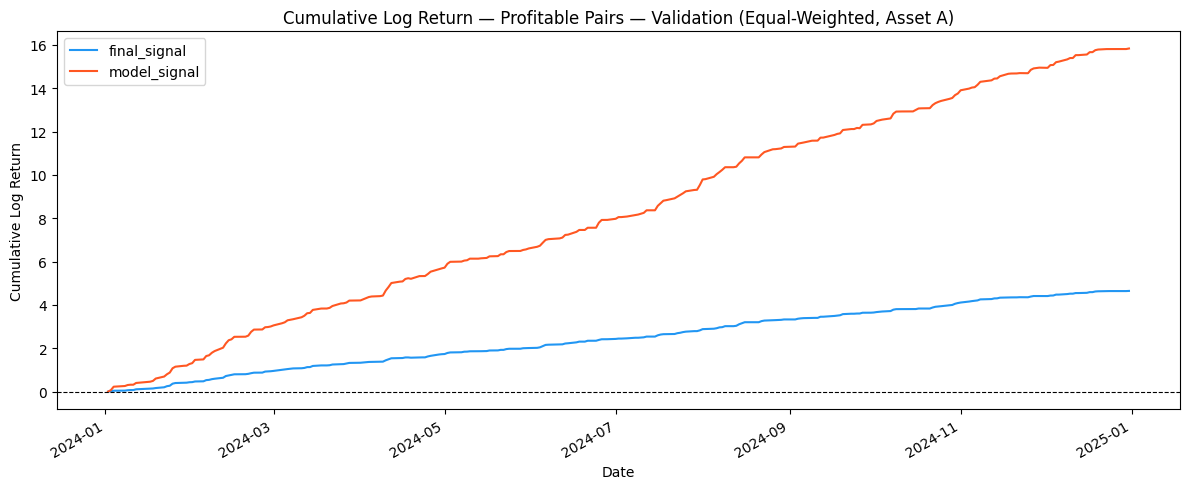

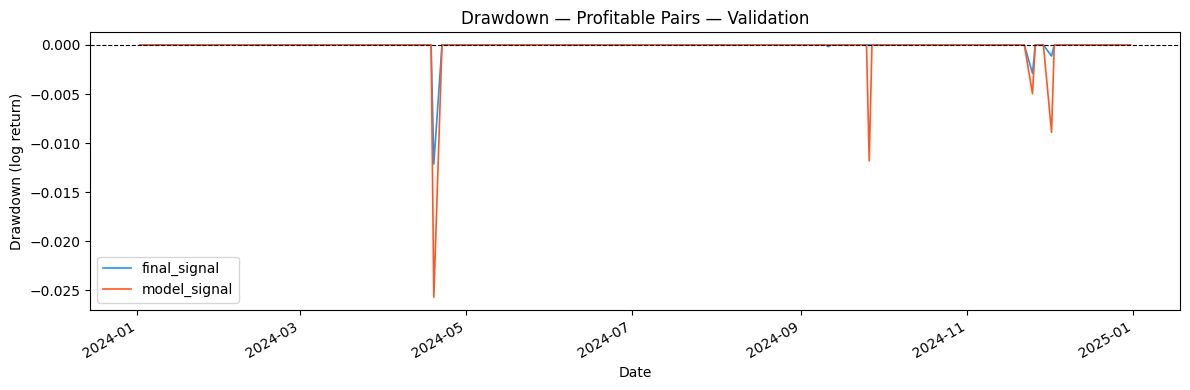

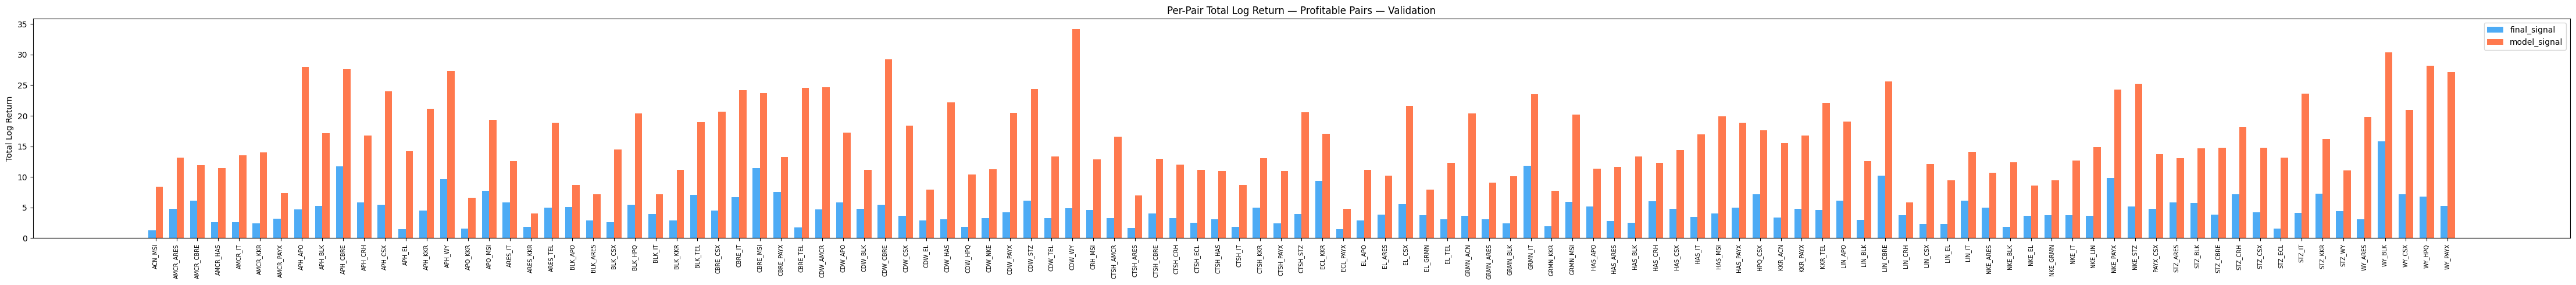

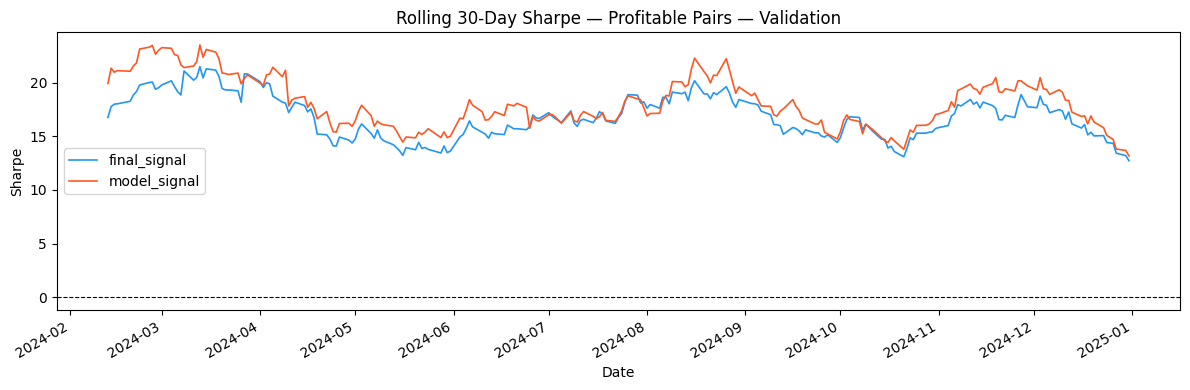

In [28]:
_orig_active = active_pairs
active_pairs = profitable_pairs_df

_, profitable_val_metrics, _ = run_backtest(val_start, val_end, 'Profitable Pairs — Validation')

active_pairs = _orig_active

profitable_val_metrics.to_csv(run_dir + '/val_metrics_profitable_pairs.csv')